In [201]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
import operator
import os


In [202]:
load_dotenv()
# Set your new OpenAI API key here
os.environ["OPENAI_API_KEY"] = "sk-NEW_KEY_HERE"

In [203]:
llm = ChatGroq(model_name="llama-3.1-8b-instant")

In [204]:
class Evaluation_Schema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay. Do NOT include the score in this field.")
    score: int = Field(description="Numeric score as a plain integer (e.g. 7). Must be between 0 and 10.", ge=0, le=10)

In [205]:
structured_model=llm.with_structured_output(Evaluation_Schema)

In [206]:
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score: Annotated[list[int], operator.add]
    avg_score:float

In [207]:
def evaluate_language(state: UPSCState):
    prompt_template = PromptTemplate(
        template=(
            "Evaluate the language of the following essay.\n"
            "Return your response with:\n"
            "- 'feedback': detailed written feedback (do NOT include the score here)\n"
            "- 'score': an integer from 0 to 10\n\n"
            "Essay:\n{essay}"
        ),
        input_variables=["essay"]
    )
    formatted_prompt = prompt_template.format(essay=state['essay'])
    response = structured_model.invoke(formatted_prompt)
    return {"language_feedback": response.feedback, "individual_score": [response.score]}

In [208]:
# Cell 8 - evaluate_analysis node
def evaluate_analysis(state: UPSCState):
    prompt_template = PromptTemplate(
        template=(
            "Evaluate the depth of analysis of the following essay.\n"
            "Return your response with:\n"
            "- 'feedback': detailed written feedback (do NOT include the score here)\n"
            "- 'score': an integer from 0 to 10\n\n"
            "Essay:\n{essay}"
        ),
        input_variables=["essay"]
    )
    formatted_prompt = prompt_template.format(essay=state['essay'])
    response = structured_model.invoke(formatted_prompt)
    return {"analysis_feedback": response.feedback, "individual_score": [response.score]}

In [209]:
# Cell 9 - evaluate_thought node
def evaluate_thought(state: UPSCState):
    prompt_template = PromptTemplate(
        template=(
            "Evaluate the clarity of thought in the following essay.\n"
            "Return your response with:\n"
            "- 'feedback': detailed written feedback (do NOT include the score here)\n"
            "- 'score': an integer from 0 to 10\n\n"
            "Essay:\n{essay}"
        ),
        input_variables=["essay"]
    )
    formatted_prompt = prompt_template.format(essay=state['essay'])
    response = structured_model.invoke(formatted_prompt)
    return {"clarity_feedback": response.feedback, "individual_score": [response.score]}

In [210]:
# Cell 10 - final_evaluation node
# FIX 7: Changed `llm.invoke(prompt)` to `llm.invoke(formatted_prompt)` (prompt was undefined)
# FIX 8: Changed `response.feedback` to just `response` since plain llm returns a string via .content
def final_evaluation(state: UPSCState):
    prompt_template = PromptTemplate(
        template=(
            "Based on the following feedback, create a summarized overall feedback.\n\n"
            "Original Essay:\n{essay}\n\n"
            "Language Feedback:\n{language_feedback}\n\n"
            "Analysis Feedback:\n{analysis_feedback}\n\n"
            "Clarity of Thought Feedback:\n{clarity}\n\n"
            "Write a concise, constructive summary combining all three perspectives."
        ),
        input_variables=["essay", "language_feedback", "analysis_feedback", "clarity"]
    )
    formatted_prompt = prompt_template.format(
        essay=state['essay'],
        language_feedback=state['language_feedback'],
        analysis_feedback=state['analysis_feedback'],
        clarity=state['clarity_feedback']
    )
    # FIX 7 & 8: use formatted_prompt, and .content gives the string directly
    response = llm.invoke(formatted_prompt).content

    avg_score = sum(state['individual_score']) / len(state['individual_score'])

    return {"overall_feedback": response, "avg_score": avg_score}

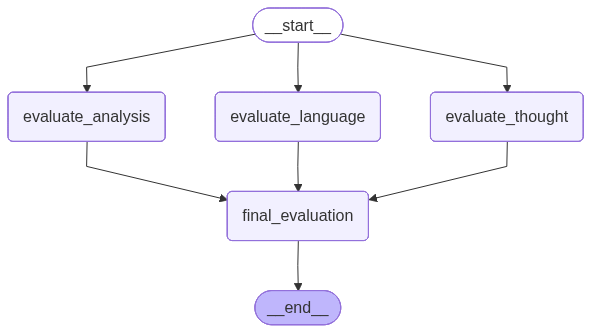

In [211]:
graph=StateGraph(UPSCState)

graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("final_evaluation",final_evaluation)

graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_thought")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_thought","final_evaluation")
graph.add_edge("final_evaluation",END)


workflow=graph.compile()
workflow

In [212]:
essay="""Mohandas Karamchand Gandhi is also known as Mahatma Gandhi is considered to be the father of this country. In the fight for independence against British rule, he was the leader of the nationalist movement. He was an Indian lawyer, political ethicist, anti-colonial nationalist, writer, and a kind-hearted person.

Birth and Childhood

Mahatma Gandhi was born on October 2, the year 1869 in a place named Porbandar, Gujrat in northwest India. He was born in a Hindu Modh family. His father Karamchand Gandhi was a political figure and also the chief minister of Porbandar. His mother named Putlibai Gandhi was the fourth wife of his father, previous wives died during childbirth. Gandhi was born in a vaishya family that's why from an early age of life he learned a lot of things such as non-injury to living beings, tolerance and vegetarianism.

Marriage

In May 1883, he was 13 years old when he got married to a girl named Kasturba Makhanji, who was also 13 years old, this marriage was arranged by their parents. They together had four sons, Harilal (1888), Manilal (1892), Ramdas (1897), Devdas (1900).

Education

In this essay on Mahatma Gandhi, let's know about Mahatma Gandhi's education Porbandar did not have enough chance of education, all the children in school used to write in dust with their fingers. However, he was lucky that his father became the chief minister of another city named Rajkot. He was average in education. At the age of 13, he lost a year at school due to marriage. He was not a shining student in the classroom or playground, but he always obeyed the given order by elders.

That's why like other kids he did not go through all the teenage life. He wanted to eat meat but never did because of their parent's beliefs. In the year of 1887, Gandhi passed the matriculation examination from the University of Bombay and joined a college in Bhavnagar named Samaldas College. It was clear for him by then that if he has to maintain his family tradition and become a high office working person in the state of Gujarat, he would have to become a barrister.

At the age of 18, he was offered to continue his studies in London and he was not very happy at Samaldas College so he accepted the offer and sailed to London in September 1888. After reaching London, He was having difficulty understanding the culture and understanding the English language. Some days after arrival he joined a Law college named Inner Temple which was one of the four London law colleges.

The transformation of changing life from a city to India studying in a college in England was not easy for him but he took his study very seriously and started to brush up his English and Latin. His vegetarianism became a very problematic subject for him as everyone around him as eating meat and he started to feel embarrassed.

Some of his new friends in London said some of the things like not eating meat will make him weak physically and mentally. But eventually, he found a vegetarian restaurant and a book that helped him understand the reason to become a vegetarian. From childhood, he wanted to eat meat himself but never did because of his parents but now in London, he was convinced that he finally embraced vegetarianism and never again thought of eating meat.

After some time he became an active member of the society called London vegetarian society and started to attend all the conferences and journals. In England not only Gandhi met Food faddists but also met some men and women who had vast knowledge about Bhagavad-Gita, Bible, Mahabharata, etc. From them, he learned a lot about Hinduism, Buddhism, Christianity and many others.

Many people he met were rebels not supporting the Victorian establishment from these people Gandhi slowly absorbed politics, personality, and more importantly ideas. He passed his study from England and became a Barrister but there was some painful news was waiting for him back at home in India. In January 1891 Gandhi's mother died while Gandhi was still in London.

He came back to India in July 1891 and started to begin the legal career but he lost his very first case in India. He soon realized that the legal profession was heavily overcrowded and he changed his path. He then was offered to be a teacher in Bombay high school but he turned it down and returned to Rajkot. With the dream of living a good life, he started to draft petitions for litigants which soon ended with the dissatisfaction of a local British officer.

Fortunately in the year 1893, he got an offer to go to Natal, South Africa and work there in an Indian firm for 1 year as it was a contract basis.

Civil Right Movement in Africa

South Africa was waiting with a lot of challenges and opportunities for him. From there he started to grow a new leaf. In South Africa 2 of his four sons were born. He had to face many difficulties there too. Once he as advocating for his client and he had to flee from the court because he was so nervous, he wasn't able to talk properly. But the bigger problem was waiting for him, as he had to face racial discrimination in South Africa.

In the journey from Durban to Pretoria, he faced a lot from, being asked to take off the turban in a court to travel on a car footboard to make room for European passenger but he refused. He was beaten by a taxi driver and thrown out of a first-class compartment but these instances made him strong and gave him the strength to fight for justice.

He started to educate others about their rights and duties. When he learned about a bill to deprive Indians of the right to vote, it was that time when others begged him to take up the fight on behalf of them. Eventually at the age of 25 in July 1894 he became a proficient political campaigner.

He drafted petitions and got them signed by hundreds of compatriots. He was not able to stop the bill but succeeded in drawing the attention of the public in Natal, England, and India. He then built many societies in Durban. He planted the seed, spirit of solidarity in the Indian community.

Very well known newspapers of that time such as The Times of London and The Statesman and Englishman of Calcutta were writing about him from this his success could be measured. He began to wear white Indian dhoti in this time-period which later became his trademark. He started a non-violent protest against tax also known as "Satyagraha" where he led a march with more than 2000 people and later he was arrested and for nine-month he was in prison.

His contribution to India's Freedom struggle and Achievements

Back in India, in the year of 1919, the British started to arrest and imprison anyone they suspect of sedition that's when Gandhi stood up and started non-violent disobedience. Gandhi's goal about Indian's independence got cleared after a tragic incident when more than 20000 protesters were getting open fired by the British army in the city of Amritsar.

400 people were killed and 1000 injured. He started the mass boycotts of British goods and institutions and told everyone to stop working for the British. In 1992 he was again got arrested and got a 6-year prison sentence. In 1930 he started the salt march and a very well known campaign of walking 390km to the Arabian Sea shores.

The salt act protesters around 60,000 including Gandhi were imprisoned. At the time of World War II, Gandhi started his campaign if Quit India to banish British rule from the country, he was again arrested and sent to prison with many other well-known leaders of Indian Congress. He met King George V on behalf of the Indian National Congress, but there was not that much progress.

After the End of the war, Britain's government was changed and this time progress was made they were willing to discuss independence for India but a tragic event followed by it partition of the country into India and Pakistan. In 1947 India gained independence. In the year of 1948, a Hindu extremist killed Gandhi. In this essay on Mahatma Gandhi, learn about the contributions made by Mahatma Gandhi!

"""

In [213]:
initial_state={
    "essay":essay
}

In [214]:
response=workflow.invoke(initial_state)

In [215]:
response

{'essay': 'Mohandas Karamchand Gandhi is also known as Mahatma Gandhi is considered to be the father of this country. In the fight for independence against British rule, he was the leader of the nationalist movement. He was an Indian lawyer, political ethicist, anti-colonial nationalist, writer, and a kind-hearted person.\n\nBirth and Childhood\n\nMahatma Gandhi was born on October 2, the year 1869 in a place named Porbandar, Gujrat in northwest India. He was born in a Hindu Modh family. His father Karamchand Gandhi was a political figure and also the chief minister of Porbandar. His mother named Putlibai Gandhi was the fourth wife of his father, previous wives died during childbirth. Gandhi was born in a vaishya family that\'s why from an early age of life he learned a lot of things such as non-injury to living beings, tolerance and vegetarianism.\n\nMarriage\n\nIn May 1883, he was 13 years old when he got married to a girl named Kasturba Makhanji, who was also 13 years old, this marr